In [ ]:
import glob
import json
import os.path


config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
BASE_DIR = data["user_dir"]

for dataset in data["datasets"]:
    dataset_dir = os.path.join(BASE_DIR, data["datasets"][dataset]["sub_dir"])
    # read the all the json files under dataset_dir
    # List all JSON files in the directory
    json_files = glob.glob(os.path.join(dataset_dir, '*.json'))
    data["datasets"][dataset]["number"] = len(json_files)
    data["datasets"][dataset]["list"] = json_files
        
    
with open(config_path, 'w') as f:
    # Use json.dump() to write JSON data
    json.dump(data, f, indent=4)   
    
    

In [1]:
import json
import os

from src.attentivetrim.sample.get_grd_batch import run_grd_batch

model = 'gpt-4-1106-preview'
config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']

for question in questions:
    print(f"Processing question: {question} on dataset: {dataset}")
    grd_output_file = f"../../../grd/{dataset}_{question}.json"
    json_obj = run_grd_batch(file_list, question, model=model)
    json_obj["model"] = model
    json_string = json.dumps(json_obj, indent=4)
    with open(grd_output_file, 'w') as f:
        f.write(json_string)

Processing question: What is the publication year of the paper? on dataset: paper


 		You are using the client GPT3, which will be removed in DSPy 2.6.
 		Changing the client is straightforward and will let you use new features (Adapters) that improve the consistency of LM outputs, especially when using chat LMs. 

 		Learn more about the changes and how to migrate at
 		https://github.com/stanfordnlp/dspy/blob/main/examples/migration.ipynb


Duration: 6.890261888504028
file: /Users/chunwei/research/ZenDB/raw_data/paper/Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game_pm.json  groundtruth:  2018  rationale:  ${produce the answer}. We look for the publication date information provided in the context, which is typically found at the beginning of the paper or in the citation details.
Duration: 4.966212272644043
file: /Users/chunwei/research/ZenDB/raw_data/paper/MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data_pm.json  groundtruth:  2015  rationale:  produce the answer. We need to locate the section of the text that provides information about the publication details of the paper. This is typically found at the beginning or end of the document and includes the title, authors, and publication date.
Duration: 6.075783014297485
file: /Users/chunwei/research/ZenDB/raw_data/paper/Pass the Ball: Enforced Turn-Taking in Activity Tracking_pm.json  groundtruth:  2015

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x102b5abb0>>
Traceback (most recent call last):
  File "/Users/chunwei/PycharmProjects/attentivetrim/.venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Duration: 6.456563949584961
file: /Users/chunwei/research/ZenDB/raw_data/paper/Turn to the Self in Human-Computer Interaction: Care of the Self in Negotiating the Human-Technology Relationship_pm.json  groundtruth:  2018  rationale:  ${produce the answer}. We look for the publication information typically found at the beginning or end of the paper. The publication year is often mentioned alongside the conference name, location, and other citation details.
Duration: 6.339967250823975
file: /Users/chunwei/research/ZenDB/raw_data/paper/A Lived Informatics Model of Personal Informatics_pm.json  groundtruth:  2015  rationale:  produce the answer. We need to locate the publication information within the context provided. The publication year is typically found in the citation details, which are often included at the beginning or end of the paper's text. We should look for a year mentioned in the context near the title, author information, or at the end of the abstract.
Duration: 4.6139860153

KeyboardInterrupt: 

In [2]:
# Get the ground truth location
from src.attentivetrim import best_substring_match
import json

model = 'gpt-4-1106-preview'
config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']

for question in questions:
    print(f"Processing question: {question} on dataset: {dataset}")
    with open(f"../../../grd/{dataset}_{question}.json", 'r') as f:
        json_obj = json.loads(f.read())
    for entry in json_obj["files"]:
        file_path = entry["file"]
        query = entry["groundtruth"]
        with open(file_path) as f_in:
            doc_dict = json.load(f_in)
        string = doc_dict["symbols"]
        total_chars = len(string)
        start, end = best_substring_match(query, string)
        entry["total_chars"] = total_chars
        entry["start"] = start
        entry["end"] = end
        print("file:", file_path, " total_chars: ", total_chars, " start: ", start, " end: ", end)
        print("ground truth: ", query)
        print ("substring: ", string[start:end])
    json_string = json.dumps(json_obj, indent=4)
    with open(f"../../../grd_loc/{dataset}_{question}-location.json", 'w') as f:
        f.write(json_string)
    
    

Processing question: What are the baselines used in the evaluation? on dataset: paper
grd: None
best match: non  score: 86 start: 2747 end: 2751
file: /Users/chunwei/research/ZenDB/raw_data/paper/Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game_pm.json  total_chars:  98366  start:  2747  end:  2751
ground truth:  None
substring:  non 
grd: None
best match: none score: 100 start: 35321 end: 35325
file: /Users/chunwei/research/ZenDB/raw_data/paper/MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data_pm.json  total_chars:  58976  start:  35321  end:  35325
ground truth:  None
substring:  none
grd: None
best match: None score: 100 start: 19377 end: 19381
file: /Users/chunwei/research/ZenDB/raw_data/paper/Pass the Ball: Enforced Turn-Taking in Activity Tracking_pm.json  total_chars:  55904  start:  19377  end:  19381
ground truth:  None
substring:  None
grd: None
best match:  one score: 86 start: 5545 end: 5549
file: /Users

Skipping /Users/chunwei/research/ZenDB/raw_data/paper/Sensor Requirements for Activity Recognition on Smart Watches_pm.json as it has no groundtruth
Skipping /Users/chunwei/research/ZenDB/raw_data/paper/Common Barriers to the Use of Patient-Generated Data Across Clinical Settings_pm.json as it has no groundtruth
Skipping /Users/chunwei/research/ZenDB/raw_data/paper/Sharing Automatically Tracked Activity Data: Implications for Therapists and People with Mobility Impairments_pm.json as it has no groundtruth
Skipping /Users/chunwei/research/ZenDB/raw_data/paper/Understanding Animals: A Critical Challenge in ACI_pm.json as it has no groundtruth
Skipping /Users/chunwei/research/ZenDB/raw_data/paper/When Personal Tracking Becomes Social: Examining the Use of Instagram for Healthy Eating_pm.json as it has no groundtruth
Skipping /Users/chunwei/research/ZenDB/raw_data/paper/The 'Self' As Barrier for Self-Management Technologies in Healthcare?_pm.json as it has no groundtruth
Skipping /Users/ch

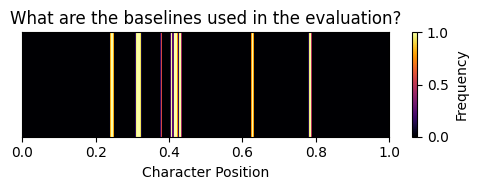

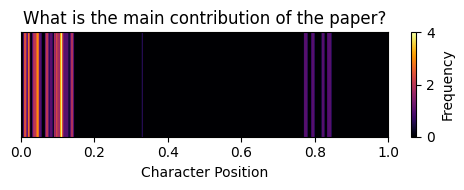

In [3]:
# Get the ground truth heatmap
import json
from src.attentivetrim.sample.get_heatmap import analyze_and_plot_location_data

config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']

for question in questions:
    task_file = f"{dataset}_{question}-location.json"
    analyze_and_plot_location_data(task_file)

In [1]:
from src.attentivetrim.sample.get_sample_prediction import run_sample_pred_batch
import os
import json

import dsp
import dspy


dsp.modules.cache_utils.cache_turn_on = False
if 'OPENAI_API_KEY' not in os.environ:
    raise ValueError("OPENAI_API_KEY not found in environment variables")
openai_key = os.environ['OPENAI_API_KEY']
turbo = dspy.OpenAI(model='gpt-4-1106-preview', api_key=openai_key, temperature=0.0)
dspy.settings.configure(lm=turbo)

# Run the model with given budget
config_path = '../../../questions/question.json'

with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']
loc_dir = "../../../grd_loc"
heatmap_dir = "../../../heatmap"
pred_dir = "../../../pred"
budgets = data["budgets"]

dataset_pred_dir = os.path.join(pred_dir, dataset)
if not os.path.exists(dataset_pred_dir):
    os.makedirs(dataset_pred_dir)

for question in questions:
    task_file = f"{dataset}_{question}-location.json"
    # read the whole file list
    with open(f"{loc_dir}/{task_file}", 'r') as f:
        json_obj = json.loads(f.read())
    whole_file_list = [entry["file"] for entry in json_obj["files"]]
    
    # read the heatmap sample file list
    with open(f"{heatmap_dir}/heatmap-{task_file}", 'r') as f:
        heatmap_json_obj = json.loads(f.read())
    sample_file_list = [entry["file"] for entry in heatmap_json_obj["chosen_files"]]
    
    # get the difference and keep the order
    diff_list = []
    for file in whole_file_list:
        if file not in sample_file_list:
            diff_list.append(file)
    
    print("whole_file_list:", len(whole_file_list), "\nsample_file_list:", len(sample_file_list), "\ndiff_list:", len(diff_list))
    

    list_of_files = diff_list
    hist_file = os.path.join(heatmap_dir, f"heatmap-{task_file}")
    for budget in budgets:
        print("question:", question, "hist_file:", hist_file, "budget:", budget)
        results = run_sample_pred_batch(list_of_files, question, hist_file, budget=budget)
        json_string = json.dumps(results, indent=4)
        pred_file = os.path.join(dataset_pred_dir, f"results-{budget}-{task_file}")
        with open(pred_file, 'w') as f:
            f.write(json_string)

whole_file_list: 99 
sample_file_list: 29 
diff_list: 70
question: What is the main contribution of the paper? hist_file: ../../../heatmap/heatmap-paper_What is the main contribution of the paper?-location.json budget: 0.002
best_start: 108 best_end: 109
leading_zeros: 0 trailing_zeros: 0 half_zeros: 0
start: 108 end: 110 index_range: 1000.0
start ratio: 0.108 end ratio: 0.11
character start: 10623 end: 10820
sample size: 197
file: /Users/chunwei/research/ZenDB/raw_data/paper/Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game_pm.json  result: None
character start: 6369 end: 6487
sample size: 118
file: /Users/chunwei/research/ZenDB/raw_data/paper/MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data_pm.json  result: None
character start: 6037 end: 6149
sample size: 112
file: /Users/chunwei/research/ZenDB/raw_data/paper/Pass the Ball: Enforced Turn-Taking in Activity Tracking_pm.json  result: None
character start: 8610 end:

In [2]:
from src.attentivetrim.tool.diverse.eval_with_grd_local_diverse import evaluate_rouge_results
from src.attentivetrim.tool.diverse.eval_with_grd_diverse import evaluate_results
from src.attentivetrim.sample.get_sample_prediction import run_sample_pred_batch
import os
import json
import dsp
import dspy


dsp.modules.cache_utils.cache_turn_on = False
if 'OPENAI_API_KEY' not in os.environ:
    raise ValueError("OPENAI_API_KEY not found in environment variables")
openai_key = os.environ['OPENAI_API_KEY']
turbo = dspy.OpenAI(model='gpt-4-1106-preview', api_key=openai_key, temperature=0.0)
dspy.settings.configure(lm=turbo)

# Run the model with given budget
config_path = '../../../questions/question.json'

with open(config_path) as f:
    data = json.load(f)

dataset = "paper"
# dataset = "notice"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']
loc_dir = "../../../grd_loc"
heatmap_dir = "../../../heatmap"
pred_dir = "../../../pred"
acc_gpt_dir = "../../../acc/gpt"
acc_rouge_dir = "../../../acc/rouge"
budgets = data["budgets"]

dataset_pred_dir = os.path.join(pred_dir, dataset)
if not os.path.exists(dataset_pred_dir):
    os.makedirs(dataset_pred_dir)

for question in questions:
    task_file = f"{dataset}_{question}-location.json"
    
    for budget in budgets:
        print("question:", question, "budget:", budget)
        results_file = os.path.join(dataset_pred_dir, f"results-{budget}-{task_file}")
        groundtruth_file = os.path.join(loc_dir, task_file)
        acc_gpt_file = os.path.join(acc_gpt_dir, f"acc-{budget}-{task_file}".replace(".json", "-acc.json"))
        acc_rouge_file = os.path.join(acc_rouge_dir, f"acc-{budget}-{task_file}".replace(".json", "-acc.json"))
        evaluate_results(results_file, groundtruth_file, acc_gpt_file)
        evaluate_rouge_results(results_file, groundtruth_file, acc_rouge_file)


question: What is the main contribution of the paper? budget: 0.002
Total matches: 0 out of 70
Total avg budget: 0.0


/Users/chunwei/PycharmProjects/attentivetrim/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/chunwei/PycharmProjects/attentivetrim/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Total matches: 0 out of 70
